# UCITS Balanced Fund — Risk Management Report

This notebook implements the risk management framework for the
**UCITS Balanced Fund** in compliance with the UCITS Directive
(2009/65/EC) and CSSF requirements for Luxembourg UCITS funds.

**Regulatory context**

UCITS imposes strict quantitative limits that must be monitored daily:

- **Absolute VaR**: 99% confidence, 20-day horizon must not exceed
  **20% of NAV** at any point
- **Relative VaR**: fund VaR must not exceed **2x** the VaR of the
  reference portfolio
- **SRRI**: Synthetic Risk and Reward Indicator disclosed in the KIID,
  reviewed monthly

Unlike AIFMD which is more principles-based, UCITS limits are hard
quantitative thresholds. A breach requires immediate action and
notification to the CSSF.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.database import get_engine, query_positions, query_nav_history
from src.enrichment import enrich_positions, get_risk_ready_df
from src.mock_bloomberg import MockBloomberg as Bloomberg
from src.risk_utils import (
    var_historical, var_parametric, var_scale,
    es_historical, es_parametric, es_scale,
    kupiec_test, christoffersen_test,
    exception_report, full_backtest_report,
    stress_equity, stress_rates, stress_credit,
    stress_fx, stress_combined, stress_historical,
    days_to_liquidate, liquidity_buckets, redemption_stress,
)

# ----------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------
FUND_ID    = 'UCITS_Balanced'
TODAY      = '2026-05-13'
ENGINE     = get_engine()
BBG        = Bloomberg()

# UCITS regulatory limits
VAR_LIMIT_ABS = 0.20   # 20% of NAV (absolute VaR limit)
VAR_LIMIT_REL = 2.0    # 2x reference portfolio (relative VaR limit)
CONFIDENCE    = 0.99   # 99% confidence level
HORIZON       = 20     # 20 trading days (UCITS standard)

plt.rcParams.update({
    'figure.facecolor' : '#0f0f0f',
    'axes.facecolor'   : '#1a1a1a',
    'axes.edgecolor'   : '#333333',
    'axes.labelcolor'  : '#cccccc',
    'xtick.color'      : '#888888',
    'ytick.color'      : '#888888',
    'text.color'       : '#cccccc',
    'grid.color'       : '#2a2a2a',
    'grid.linestyle'   : '--',
    'font.family'      : 'monospace',
    'figure.dpi'       : 120,
})

ACCENT  = '#00ff9f'
ACCENT2 = '#ff6b35'
ACCENT3 = '#4fc3f7'

print(f'Fund      : {FUND_ID}')
print(f'Date      : {TODAY}')
print(f'VaR limit : {VAR_LIMIT_ABS*100:.0f}% NAV (absolute)')
print(f'VaR limit : {VAR_LIMIT_REL:.0f}x reference (relative)')
print(f'Confidence: {CONFIDENCE*100:.0f}%')
print(f'Horizon   : {HORIZON} days')

MockBloomberg: connected (simulation mode)
Swap import to RealBloomberg for production use.
Fund      : UCITS_Balanced
Date      : 2026-05-13
VaR limit : 20% NAV (absolute)
VaR limit : 2x reference (relative)
Confidence: 99%
Horizon   : 20 days


## 1. Load and Validate Positions

Load today's UCITS Balanced Fund positions from the daily fund
administrator export and validate UCITS-specific requirements.
Unlike AIFM funds, UCITS imposes strict eligibility and
concentration rules that must be checked at the position level
before any risk calculation begins.

In [2]:
# ----------------------------------------------------------------
# Load positions from daily fund admin export
# ----------------------------------------------------------------
from pathlib import Path

EXPORT_DIR = Path('..') / 'data' / 'daily_exports'
export_file = EXPORT_DIR / f'{FUND_ID}_{TODAY}.xlsx'

# load from daily export (simulates receiving fund admin file)
positions = pd.read_excel(export_file)
print(f'Loaded {len(positions)} positions from {export_file.name}')

# also load from database for historical analysis
all_positions = query_positions(ENGINE, FUND_ID)
nav = positions['market_value_eur'].sum()

print(f'\n--- Portfolio snapshot ({TODAY}) ---')
print(f'NAV              : EUR {nav:,.0f}')
print(f'Number of positions: {len(positions)}')
print(f'History available  : {all_positions["date"].nunique()} days')

# asset class breakdown
print(f'\nAsset class breakdown:')
breakdown = positions.groupby('asset_class')['market_value_eur'].sum()
for ac, mv in breakdown.sort_values(ascending=False).items():
    pct = mv / nav * 100
    print(f'  {ac:15s}: EUR {mv:>15,.0f}  ({pct:.1f}%)')

# ----------------------------------------------------------------
# UCITS specific validations
# ----------------------------------------------------------------
print(f'\n--- UCITS compliance checks ---')

# 1. all positions long only (UCITS cannot short)
has_shorts = (positions['market_value_eur'] < 0).any()
print(f'  Long only        : {"FAIL - short positions detected" if has_shorts else "OK"}')

# 2. no single position > 10% NAV
# ETFs are exempt: they are diversified instruments
# compute weight_abs first
positions['weight_abs'] = positions['market_value_eur'].abs() / nav * 100

# then filter non-ETF
non_etf     = positions[positions['sub_asset_class'] != 'ETF'].copy()
breaches_10 = non_etf[non_etf['weight_abs'] > 10]

if len(breaches_10) > 0:
    print(f'  10% limit        : FLAG - {len(breaches_10)} non-ETF positions exceed limit')
    for _, row in breaches_10.iterrows():
        print(f'    {row["instrument_name"]:<30}: {row["weight_abs"]:.1f}%')
else:
    print(f'  10% limit        : OK (ETFs exempt as diversified instruments)')

# 3. all instruments UCITS eligible (listed, liquid)
illiquid = positions[positions['adv_eur'] == 0]
illiquid = illiquid[illiquid['asset_class'] != 'Cash']
if len(illiquid) > 0:
    print(f'  Liquidity        : FLAG - {len(illiquid)} illiquid instruments')
    for _, row in illiquid.iterrows():
        print(f'    {row["instrument_name"]}')
else:
    print(f'  Liquidity        : OK - all instruments liquid')

# 4. weights sum to 100%
weight_sum = positions['weight_pct'].sum()
print(f'  Weights sum      : {weight_sum:.2f}% '
      f'({"OK" if abs(weight_sum - 100) < 1 else "FLAG"})')

Loaded 9 positions from UCITS_Balanced_2026-05-13.xlsx

--- Portfolio snapshot (2026-05-13) ---
NAV              : EUR 411,372,681
Number of positions: 9
History available  : 250 days

Asset class breakdown:
  Equity         : EUR     299,738,253  (72.9%)
  Bond           : EUR      61,649,353  (15.0%)
  Cash           : EUR      25,000,000  (6.1%)
  Commodity      : EUR      24,985,075  (6.1%)

--- UCITS compliance checks ---
  Long only        : OK
  10% limit        : OK (ETFs exempt as diversified instruments)
  Liquidity        : OK - all instruments liquid
  Weights sum      : 100.00% (OK)


## 2. Absolute VaR

The UCITS absolute VaR limit requires that the 99% confidence,
20-day VaR does not exceed **20% of NAV** at any point. This is
monitored daily and reported to the CSSF on request.

$$VaR_{20d}^{99\%} = VaR_{1d}^{99\%} \cdot \sqrt{20}$$

Two methods are computed and compared:
- **Historical simulation**: no distribution assumption, uses actual
  fund P&L history (pulls from empirical quantile)
- **Parametric (Student-t)**: uses the sample mean $\mu$ and
  standard deviation $\sigma$ estimated from the 250-day P&L
  history as inputs to the Student-t quantile formula
  
**Data window**: both methods use the last 250 trading days (~1 year)
of daily fund P&L as the estimation window. This is the regulatory
minimum under UCITS. A longer window captures more market regimes
but is slower to react to current conditions; a shorter window is
more reactive but less stable.

For historical simulation, 250 observations give 2-3 data points
in the 1% tail, which is the minimum for a reliable quantile estimate.
For parametric VaR, the same window is used to estimate $\mu$ and
$\sigma$ which feed into the Student-t formula.

**New funds**: when the fund has less than 250 days of history,
the standard practice is to use a **proxy portfolio** with the
same asset class composition and weights applied to a benchmark
index with sufficient history. The CSSF accepts this approach
for funds in their first year of operation, provided the proxy
methodology is documented in the risk management policy.

P&L history: 249 daily observations
Mean daily return : 0.0459%
Daily volatility  : 0.6552%
Ann. volatility   : 10.40%

--- VaR results ---
Method                    1-day     20-day      Limit  Utilization   Status
---------------------------------------------------------------------------
Historical               1.388%     6.208%        20%        31.0%     🟢 OK
Parametric               2.159%     9.655%        20%        48.3%     🟢 OK

--- Expected Shortfall (historical) ---
ES 1-day  : 1.628%
ES 20-day : 7.282%
ES/VaR ratio: 1.17x (expected >1.0)


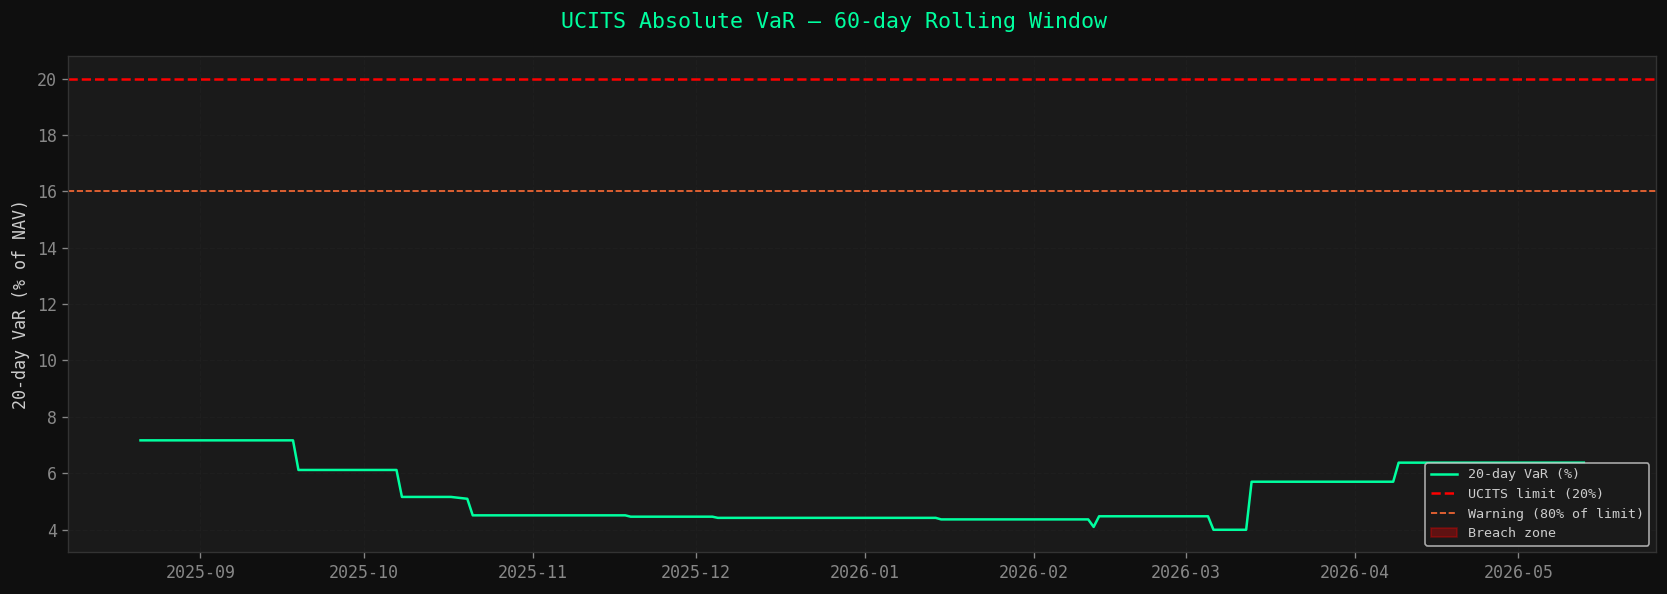

In [ ]:
# ----------------------------------------------------------------
# Absolute VaR computation
# ----------------------------------------------------------------

# get P&L history from NAV
nav_history = query_nav_history(ENGINE, FUND_ID)
pnl         = nav_history['pnl_pct'].dropna().values

print(f'P&L history: {len(pnl)} daily observations')
print(f'Mean daily return : {pnl.mean()*100:.4f}%')
print(f'Daily volatility  : {pnl.std()*100:.4f}%')
print(f'Ann. volatility   : {pnl.std()*np.sqrt(252)*100:.2f}%')

# --- Historical simulation VaR ---
var_hist_1d  = var_historical(pnl, confidence=CONFIDENCE)
var_hist_20d = var_scale(var_hist_1d, horizon=HORIZON)

# --- Parametric VaR (Student-t) ---
mu           = pnl.mean()
sigma        = pnl.std()
var_para_1d  = var_parametric(mu=mu, sigma=sigma,
                               confidence=CONFIDENCE, dist='t', df=5)
var_para_20d = var_scale(var_para_1d, horizon=HORIZON)

# --- ES ---
es_hist_1d   = es_historical(pnl, confidence=CONFIDENCE)
es_hist_20d  = es_scale(es_hist_1d, horizon=HORIZON)

print(f'\n--- VaR results ---')
print(f'{"Method":<20} {"1-day":>10} {"20-day":>10} '
      f'{"Limit":>10} {"Utilization":>12} {"Status":>8}')
print('-' * 75)

for method, var_1d, var_20d in [
    ('Historical',  var_hist_1d,  var_hist_20d),
    ('Parametric',  var_para_1d,  var_para_20d),
]:
    utilization = var_20d / VAR_LIMIT_ABS * 100
    status      = ('🔴 BREACH' if var_20d > VAR_LIMIT_ABS else
                   # 80% threshold for warning zone = var 16%+
                   '🟡 WARNING' if var_20d > VAR_LIMIT_ABS * 0.80 else
                   '🟢 OK')
    print(f'{method:<20} {var_1d*100:>9.3f}% {var_20d*100:>9.3f}% '
          f'{VAR_LIMIT_ABS*100:>9.0f}% {utilization:>11.1f}% {status:>8}')

print(f'\n--- Expected Shortfall (historical) ---')
print(f'ES 1-day  : {es_hist_1d*100:.3f}%')
print(f'ES 20-day : {es_hist_20d*100:.3f}%')
print(f'ES/VaR ratio: {es_hist_1d/var_hist_1d:.2f}x '
      f'(expected >1.0)')

# ----------------------------------------------------------------
# Rolling VaR chart
# ----------------------------------------------------------------
window   = 60
rolling_var = pd.Series([
    var_historical(pnl[max(0, i-window):i], confidence=CONFIDENCE)
    for i in range(window, len(pnl)+1)
])
dates_plot = nav_history['date'].iloc[window:].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('UCITS Absolute VaR — 60-day Rolling Window',
             fontsize=13, color=ACCENT)

ax.plot(dates_plot, rolling_var * np.sqrt(HORIZON) * 100,
        color=ACCENT, lw=1.5, label='20-day VaR (%)')
ax.axhline(VAR_LIMIT_ABS * 100, color='red', lw=1.5,
           ls='--', label=f'UCITS limit ({VAR_LIMIT_ABS*100:.0f}%)')
ax.axhline(VAR_LIMIT_ABS * 80, color=ACCENT2, lw=1,
           ls='--', label='Warning (80% of limit)')
ax.fill_between(dates_plot,
                rolling_var * np.sqrt(HORIZON) * 100,
                VAR_LIMIT_ABS * 100,
                where=rolling_var * np.sqrt(HORIZON) > VAR_LIMIT_ABS,
                color='red', alpha=0.3, label='Breach zone')
ax.set_ylabel('20-day VaR (% of NAV)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The rolling VaR chart below is for internal monitoring only.
The single regulatory VaR figure computed from the full 250-day
window is what is reported to the CSSF. The rolling chart shows
how the risk profile has evolved over time, making gradual
increases in portfolio risk visible before they become a
regulatory concern.

**Expected Shortfall (ES)** measures the average loss in the worst
scenarios beyond the VaR threshold. It is teh conditional expected loss when VAR is breached.

$$ES_{\alpha} = -\mathbb{E}[R \mid R < -VaR_{\alpha}]$$

For UCITS reporting, historical ES is the standard. Parametric ES
under the Student-t distribution:

$$ES_{\alpha} = \sigma \cdot \frac{f_t(t_{\alpha}) \cdot (\nu + t_{\alpha}^2)}{(\nu - 1)(1 - \alpha)}$$

is shown below for completeness. Parametric ES is not required by UCITS or AIFMD regulation and is more commonly encountered in the banking context under Basel IV, where Expected Shortfall at 97.5% replaced VaR as the primary capital measure under FRTB.

In [5]:
# ----------------------------------------------------------------
# Expected Shortfall: parametric (Student-t) for completeness
# ----------------------------------------------------------------

es_para_1d  = es_parametric(sigma=sigma, mu=mu,
                             confidence=CONFIDENCE, dist='t', df=5)
es_para_20d = es_scale(es_para_1d, horizon=HORIZON)

print('--- Expected Shortfall comparison ---')
print(f'{"Method":<20} {"ES 1-day":>10} {"ES 20-day":>10} {"ES/VaR":>8}')
print('-' * 52)
print(f'{"Historical":<20} {es_hist_1d*100:>9.3f}% '
      f'{es_hist_20d*100:>9.3f}% '
      f'{es_hist_1d/var_hist_1d:>7.2f}x')
print(f'{"Parametric (t)":<20} {es_para_1d*100:>9.3f}% '
      f'{es_para_20d*100:>9.3f}% '
      f'{es_para_1d/var_para_1d:>7.2f}x')

print(f'\nNote: ES > VaR always holds by construction.')
print(f'ES/VaR ratio reflects tail heaviness: '
      f'higher ratio = fatter tails.')

--- Expected Shortfall comparison ---
Method                 ES 1-day  ES 20-day   ES/VaR
----------------------------------------------------
Historical               1.628%     7.282%    1.17x
Parametric (t)           2.871%    12.841%    1.33x

Note: ES > VaR always holds by construction.
ES/VaR ratio reflects tail heaviness: higher ratio = fatter tails.


## 3. Relative VaR

The UCITS relative VaR limit requires that the fund VaR does not exceed **2x the VaR of the reference portfolio**. This approach is used when the fund has a clear benchmark and is more appropriate than the absolute limit for funds whose risk profile is defined relative to a market index.

$$\text{Relative VaR} = \frac{VaR_{fund}}{VaR_{reference}} \leq 2$$

The reference portfolio for UCITS Balanced is a standard 60/40 allocation: 60% MSCI World (proxied by SPY) and 40% Bloomberg Global Aggregate (proxied by TLT). This is documented in the fund's risk management policy and approved by the CSSF.

Reference portfolio: 60% SPY + 40% TLT
Reference history  : 261 days
Reference daily vol: 1.0373%
Fund daily vol     : 0.6552%

--- Relative VaR ---
Fund VaR 20d      : 6.208%
Reference VaR 20d : 9.938%
Relative VaR ratio: 0.62x (limit: 2x)  🟢 OK
Utilization       : 31.2% of limit


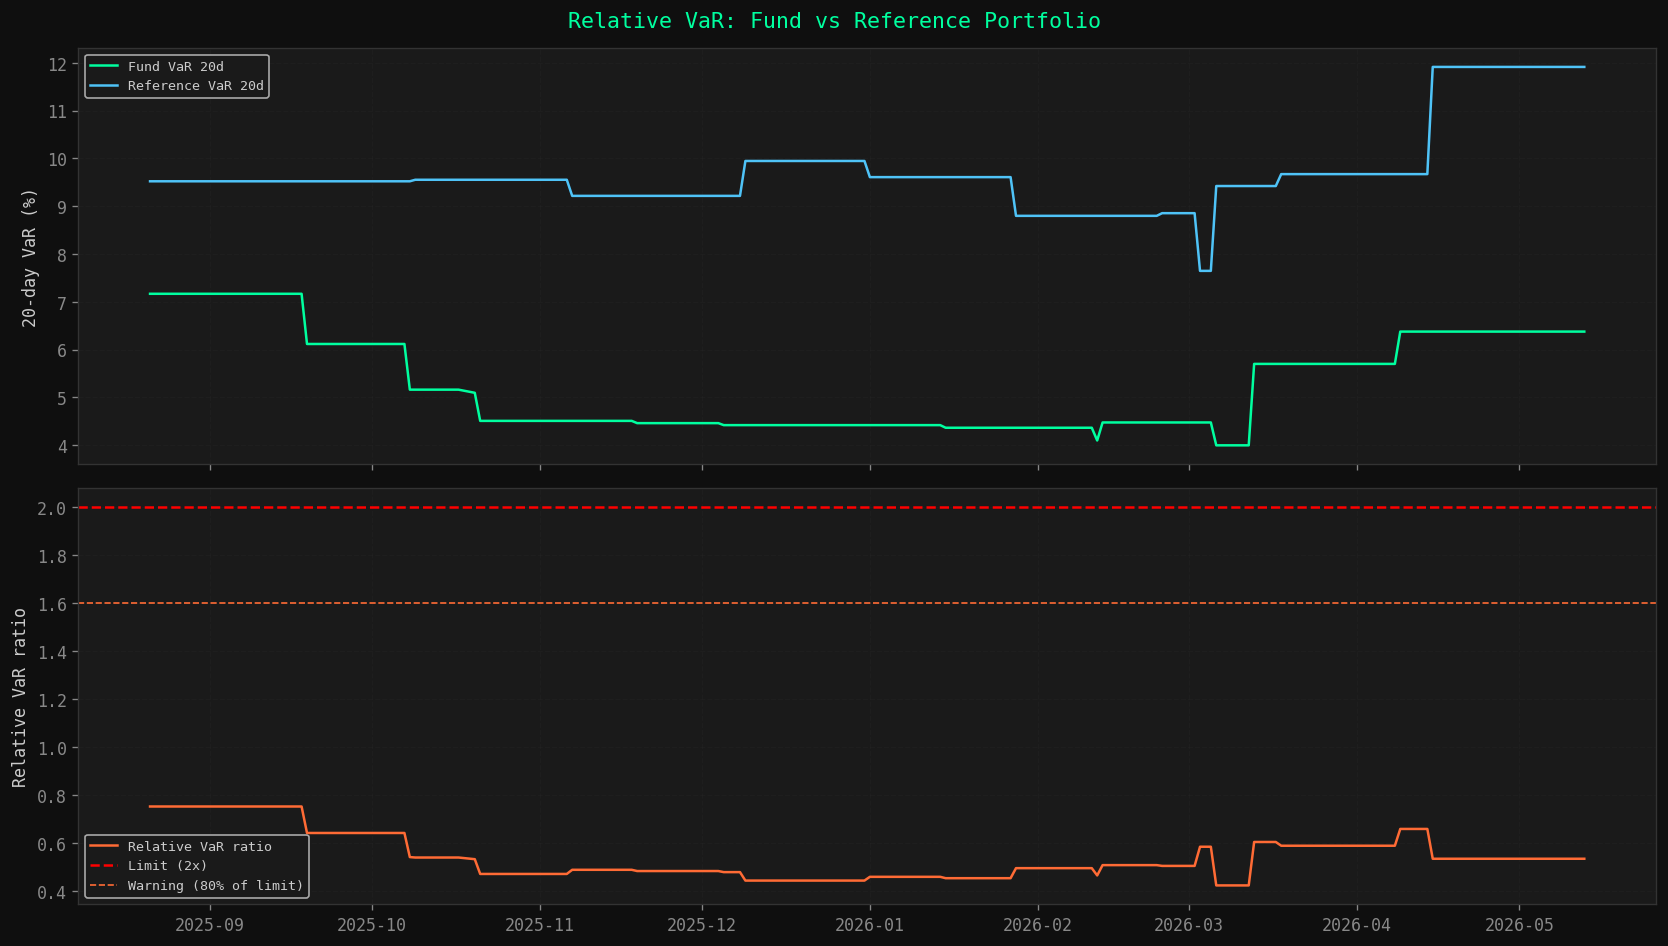

In [ ]:
# ----------------------------------------------------------------
# Relative VaR
# ----------------------------------------------------------------

# reference portfolio: 60% SPY, 40% TLT
# reference portfolio: 60% SPY (MSCI World proxy), 40% IEAG (EUR Govt Bond proxy)
w_eq  = 0.60
w_bd  = 0.40

spy_hist  = BBG.bdh('SPY US Equity', 'PX_LAST', '2025-05-13', TODAY)
ieag_hist = BBG.bdh('IEAG LN Equity', 'PX_LAST', '2025-05-13', TODAY)

spy_ret  = spy_hist['PX_LAST'].pct_change().dropna()
ieag_ret = ieag_hist['PX_LAST'].pct_change().dropna()

ref_ret = (w_eq * spy_ret + w_bd * ieag_ret).dropna().values

print(f'Reference portfolio: {w_eq*100:.0f}% SPY + {w_bd*100:.0f}% TLT')
print(f'Reference history  : {len(ref_ret)} days')
print(f'Reference daily vol: {ref_ret.std()*100:.4f}%')
print(f'Fund daily vol     : {pnl.std()*100:.4f}%')

# VaR for reference portfolio
var_ref_1d  = var_historical(ref_ret, confidence=CONFIDENCE)
var_ref_20d = var_scale(var_ref_1d, horizon=HORIZON)

# relative VaR ratio
relative_var = var_hist_20d / var_ref_20d
status       = ('🔴 BREACH' if relative_var > VAR_LIMIT_REL else
                '🟡 WARNING' if relative_var > VAR_LIMIT_REL * 0.80 else
                '🟢 OK')

print(f'\n--- Relative VaR ---')
print(f'Fund VaR 20d      : {var_hist_20d*100:.3f}%')
print(f'Reference VaR 20d : {var_ref_20d*100:.3f}%')
print(f'Relative VaR ratio: {relative_var:.2f}x '
      f'(limit: {VAR_LIMIT_REL:.0f}x)  {status}')
print(f'Utilization       : {relative_var/VAR_LIMIT_REL*100:.1f}% of limit')

# ----------------------------------------------------------------
# Chart: fund vs reference portfolio rolling VaR
# ----------------------------------------------------------------
window = 60
min_len = min(len(pnl), len(ref_ret))
pnl_aligned = pnl[-min_len:]
ref_aligned = ref_ret[-min_len:]

rolling_var_fund = pd.Series([
    var_historical(pnl_aligned[max(0,i-window):i], CONFIDENCE)
    for i in range(window, min_len+1)
])
rolling_var_ref = pd.Series([
    var_historical(ref_aligned[max(0,i-window):i], CONFIDENCE)
    for i in range(window, min_len+1)
])
rolling_ratio = rolling_var_fund / rolling_var_ref
dates_rel     = nav_history['date'].iloc[window:].reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Relative VaR: Fund vs Reference Portfolio',
             fontsize=13, color=ACCENT)

axes[0].plot(dates_rel, rolling_var_fund * np.sqrt(HORIZON) * 100,
             color=ACCENT, lw=1.5, label='Fund VaR 20d')
axes[0].plot(dates_rel, rolling_var_ref * np.sqrt(HORIZON) * 100,
             color=ACCENT3, lw=1.5, label='Reference VaR 20d')
axes[0].set_ylabel('20-day VaR (%)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(dates_rel, rolling_ratio,
             color=ACCENT2, lw=1.5, label='Relative VaR ratio')
axes[1].axhline(VAR_LIMIT_REL, color='red', lw=1.5,
                ls='--', label=f'Limit ({VAR_LIMIT_REL:.0f}x)')
axes[1].axhline(VAR_LIMIT_REL * 0.80, color=ACCENT2, lw=1,
                ls='--', label='Warning (80% of limit)')
axes[1].set_ylabel('Relative VaR ratio')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()